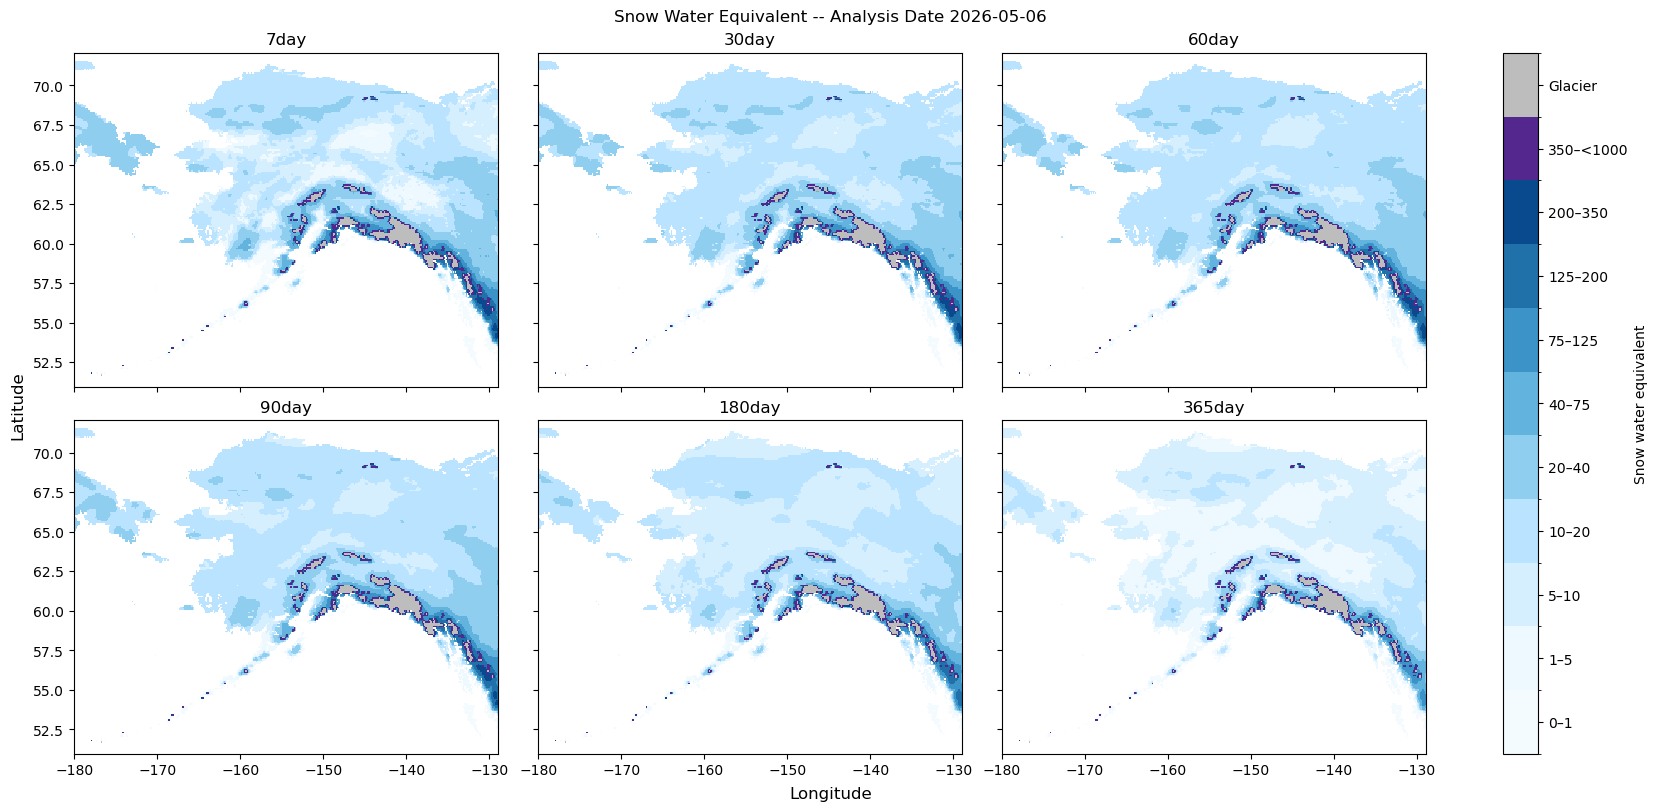

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap

data_dir = Path("snap/drought_outputs")

all_files = [
    Path("snap/drought_outputs/drought_indices_1day.nc"),
    Path("snap/drought_outputs/drought_indices_7day.nc"),
    Path("snap/drought_outputs/drought_indices_30day.nc"),
    Path("snap/drought_outputs/drought_indices_60day.nc"),
    Path("snap/drought_outputs/drought_indices_90day.nc"),
    Path("snap/drought_outputs/drought_indices_180day.nc"),
    Path("snap/drought_outputs/drought_indices_365day.nc"),
]

variable_key = "swe"
long_name = "Snow Water Equivalent"

# Discrete SWE categories.
#
# The final bin isolates the ERA5-Land special glacier value of 1000.
# The upper non-glacier bound is set to 999.5 so that values equal to
# 1000 fall cleanly into the glacier category.
bounds = [
    0,
    1,
    5,
    10,
    20,
    40,
    75,
    125,
    200,
    350,
    999.5,
    1000.5,
]

colors = [
    "#f3fbff",  # 0 to 1: little/no snow, but not pure white
    "#eef8ff",  # 1 to 5
    "#d6efff",  # 5 to 10
    "#b9e3ff",  # 10 to 20
    "#8fceef",  # 20 to 40
    "#63b3df",  # 40 to 75
    "#3c93c8",  # 75 to 125
    "#2070aa",  # 125 to 200
    "#084a8d",  # 200 to 350
    "#54278f",  # 350 to <1000
    "#bdbdbd",  # Glacier
]

cmap = ListedColormap(colors)
cmap.set_bad("white")  # ocean / masked cells

norm = BoundaryNorm(bounds, cmap.N, clip=True)

cbar_labels = [
    "0–1",
    "1–5",
    "5–10",
    "10–20",
    "20–40",
    "40–75",
    "75–125",
    "125–200",
    "200–350",
    "350–<1000",
    "Glacier",
]

# Put colorbar ticks at bin centers.
cbar_ticks = [
    0.5,
    3,
    7.5,
    15,
    30,
    57.5,
    100,
    162.5,
    275,
    675,
    1000,
]

short_window_files = [all_files[0]]
long_window_files = all_files[1::]


def open_nc(path: str | Path) -> xr.Dataset:
    """Open a NetCDF file with decoding enabled."""
    return xr.open_dataset(path)


def plot_variable_across_files(
    paths: list[str | Path],
    figsize_per_panel: tuple[float, float] = (5.5, 4.0),
    save_path: str | Path | None = None,
) -> plt.Figure:
    """Compare snow water equivalent across multiple NetCDF files."""

    ncols = 3
    nrows = 2

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    opened: list[tuple[Path, xr.Dataset]] = []

    for path in paths:
        p = Path(path)
        ds = open_nc(p)
        opened.append((p, ds))

    mesh = None

    for ax, (path, ds) in zip(axes.flat, opened, strict=False):
        # Mask ocean using smd, assuming smd is NaN over ocean.
        # This avoids treating ocean SWE = 0 as valid land snow-free area.
        da = ds[variable_key].where(ds["smd"].notnull())

        lon = ds["longitude"].values
        lat = ds["latitude"].values

        mesh = ax.pcolormesh(
            lon,
            lat,
            da.values,
            shading="auto",
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(Path(path).stem.split("_")[-1])
        ax.label_outer()
        ax.set_facecolor("white")

    if mesh is None:
        raise ValueError("No input files were provided.")

    fig.supxlabel("Longitude")
    fig.supylabel("Latitude")

    cbar = fig.colorbar(
        mesh,
        ax=axes.ravel().tolist(),
        boundaries=bounds,
        ticks=cbar_ticks,
        spacing="uniform",
    )

    cbar.set_ticklabels(cbar_labels)
    cbar.set_label("Snow water equivalent")

    fig.suptitle(
        f"{long_name} -- Analysis Date {analysis_date}",
        fontsize=12,
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

plot_variable_across_files(long_window_files, save_path="swe.png")